In [ ]:
import numpy as np
import pandas as pd
import json
import joblib
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute           import SimpleImputer
from sklearn.calibration      import CalibratedClassifierCV
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.base             import BaseEstimator, ClassifierMixin
from sklearn.model_selection  import (StratifiedGroupKFold,
                                       train_test_split)
from sklearn.metrics          import (roc_auc_score, roc_curve,
                                       precision_recall_curve,
                                       average_precision_score,
                                       brier_score_loss)
from scipy.stats import ks_2samp

import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import mlflow
import mlflow.sklearn
import shap

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
})
BLUE='#2E86C1'; RED='#E74C3C'; GRN='#1E8449'; ORG='#E67E22'

RUN_FAST        = True
N_OPTUNA_TRIALS = 20 if RUN_FAST else 150
N_CV_FOLDS      = 3  if RUN_FAST else 5
REPORTS_DIR     = './reports'
MODELS_DIR      = '../models'
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

In [40]:
# LOAD DATA
train_old = pd.read_parquet('../data/processed/train_features.parquet')
val_old   = pd.read_parquet('../data/processed/val_features.parquet')
test_old  = pd.read_parquet('../data/processed/test_features.parquet')

# Recombine into one dataframe and re-split properly
df = pd.concat([train_old, val_old, test_old], ignore_index=True)

# Drop any old split column — we will assign a new one
if 'split' in df.columns:
    df.drop(columns=['split'], inplace=True)

print(f'Combined dataset: {df.shape}')
print(f'Overall DR: {df["target"].mean():.2%}')
print(f'Unique users: {df["user_id"].nunique():,}')

TARGET      = 'target'
IDENTIFIERS = ['user_id', 'loan_number', 'loan_sequence_group']
PRIOR_COLS  = ['prior_loan_count', 'prior_default_rate',
               'ever_defaulted', 'days_since_last_loan']

all_cols        = [c for c in df.columns
                   if c not in [TARGET] + IDENTIFIERS]
FEATURES_C1     = [c for c in all_cols if c not in PRIOR_COLS]
FEATURES_C2PLUS = all_cols

SPW = (df[TARGET] == 0).sum() / (df[TARGET] == 1).sum()
print(f'scale_pos_weight: {SPW:.2f}')

Combined dataset: (619655, 29)
Overall DR: 20.79%
Unique users: 168,597
scale_pos_weight: 3.81


In [ ]:
# RANDOM GROUPED USER SPLIT  70 / 15 / 15

user_info = (df.groupby('user_id')
               .agg(target_rate=('target', 'mean'), n_loans=('target', 'count'))
               .reset_index())

# Stratify by majority class per user
user_info['label'] = (user_info['target_rate'] >= 0.5).astype(int)

# Split users 70 / 30
train_users, temp_users = train_test_split(
    user_info['user_id'],
    test_size=0.30,
    stratify=user_info['label'],
    random_state=SEED,
)

# Split remaining 30% into 15 / 15
temp_labels = user_info.set_index('user_id').loc[temp_users, 'label']
val_users, test_users = train_test_split(
    temp_users,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED,
)

train_set = set(train_users)
val_set   = set(val_users)
test_set  = set(test_users)

df['split'] = 'train'
df.loc[df['user_id'].isin(val_set),  'split'] = 'val'
df.loc[df['user_id'].isin(test_set), 'split'] = 'test'

# Leakage check
assert not (train_set & val_set),  'Overlap: train ∩ val'
assert not (train_set & test_set), 'Overlap: train ∩ test'
assert not (val_set   & test_set), 'Overlap: val ∩ test'
print('\nLeakage check passed.')

# Verify distributions
print('\nSplit summary:')
for s in ['train', 'val', 'test']:
    sub  = df[df['split'] == s]
    c1   = sub[sub['is_first_loan'] == 1]
    c2   = sub[sub['is_first_loan'] == 0]
    bur  = (sub['distinct_lender_count'] > 0).mean()
    print(f"  {s:6s}: {len(sub):>7,} loans | "
          f"{sub['user_id'].nunique():>5,} users | "
          f"DR={sub['target'].mean():.2%} | "
          f"bureau={bur:.1%} | "
          f"C1 DR={c1['target'].mean():.2%} | "
          f"C2+ DR={c2['target'].mean():.2%}")

# Save new splits
for s in ['train', 'val', 'test']:
    sub = df[df['split'] == s].reset_index(drop=True)
    sub.to_parquet(f'../data/processed/{s}_features.parquet', index=False)
    print(f'Saved {s}: {sub.shape}')

train = df[df['split'] == 'train'].reset_index(drop=True)
val   = df[df['split'] == 'val'].reset_index(drop=True)
test  = df[df['split'] == 'test'].reset_index(drop=True)


Leakage check passed.

Split summary:
  train : 434,761 loans | 118,017 users | DR=20.73% | bureau=37.3% | C1 DR=42.99% | C2+ DR=15.20%
  val   :  92,935 loans | 25,290 users | DR=20.80% | bureau=38.0% | C1 DR=42.69% | C2+ DR=15.39%
  test  :  91,959 loans | 25,290 users | DR=21.07% | bureau=37.6% | C1 DR=42.88% | C2+ DR=15.56%
Saved train: (434761, 30)
Saved val: (92935, 30)
Saved test: (91959, 30)


In [42]:
# SEGMENT HELPER
def segment(df_split, seg):
    mask     = (df_split['is_first_loan'] == 1) if seg == 'c1' \
               else (df_split['is_first_loan'] == 0)
    features = FEATURES_C1 if seg == 'c1' else FEATURES_C2PLUS
    sub      = df_split[mask].copy()
    return sub[features], sub[TARGET], sub['user_id']

X_train_c1, y_train_c1, g_train_c1 = segment(train, 'c1')
X_val_c1, y_val_c1, _ = segment(val, 'c1')
X_test_c1, y_test_c1, _ = segment(test, 'c1')

X_train_c2, y_train_c2, g_train_c2 = segment(train, 'c2plus')
X_val_c2, y_val_c2, _ = segment(val, 'c2plus')
X_test_c2, y_test_c2, _ = segment(test, 'c2plus')

print(f'\nC1  train={len(X_train_c1):,} DR={y_train_c1.mean():.2%}')
print(f'C2+ train={len(X_train_c2):,} DR={y_train_c2.mean():.2%}')


C1  train=86,570 DR=42.99%
C2+ train=348,191 DR=15.20%


In [47]:
# PREPROCESSORS
def get_column_types(X):
    num = X.select_dtypes(include=[np.number]).columns.tolist()
    cat = X.select_dtypes(include=['object','category']).columns.tolist()
    return num, cat


def build_lr_rf_preprocessor(X):
    num, cat = get_column_types(X)
    num_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
    ])
    pre = ColumnTransformer([
        ('num', num_pipe, num),
        ('cat', cat_pipe, cat),
    ], remainder='drop', sparse_threshold=0.3)
    return pre, num, cat


def build_lgbm_preprocessor(X):
    num, cat = get_column_types(X)
    num_pipe = Pipeline([('imp', SimpleImputer(strategy='median'))])
    cat_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ])
    pre = ColumnTransformer([
        ('num', num_pipe, num),
        ('cat', cat_pipe, cat),
    ], remainder='drop')
    return pre, num, cat

In [44]:
# EVALUATION HELPERS
def evaluate(model, X, y, split_name='val', seg='C1'):
    p      = model.predict_proba(X)[:, 1]
    auc    = roc_auc_score(y, p)
    gini   = 2 * auc - 1
    brier  = brier_score_loss(y, p)
    pr_auc = average_precision_score(y, p)
    ks, _  = ks_2samp(p[y == 1], p[y == 0])
    m = {f'{split_name}_auc':    round(auc,   4),
         f'{split_name}_gini':   round(gini,  4),
         f'{split_name}_ks':     round(ks,    4),
         f'{split_name}_pr_auc': round(pr_auc,4),
         f'{split_name}_brier':  round(brier, 4)}
    print(f'  [{seg}|{split_name}] AUC={auc:.4f} Gini={gini:.4f} '
          f'KS={ks:.4f} PR-AUC={pr_auc:.4f} Brier={brier:.4f}')
    return m, p

def plot_evaluation(model, Xv, yv, Xt, yt, name, seg):
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)
    pv  = model.predict_proba(Xv)[:, 1]
    pt  = model.predict_proba(Xt)[:, 1]

    ax1 = fig.add_subplot(gs[0,0])
    for p,y,lbl,c in [(pv,yv,'Val',BLUE),(pt,yt,'Test',RED)]:
        fpr,tpr,_ = roc_curve(y,p)
        ax1.plot(fpr,tpr,c=c,lw=2,
                 label=f'{lbl} AUC={roc_auc_score(y,p):.4f}')
    ax1.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax1.set_title(f'{name} [{seg}] ROC'); ax1.legend()

    ax2 = fig.add_subplot(gs[0,1])
    for p,y,lbl,c in [(pv,yv,'Val',BLUE),(pt,yt,'Test',RED)]:
        pr,rec,_ = precision_recall_curve(y,p)
        ax2.plot(rec,pr,c=c,lw=2,
                 label=f'{lbl} PR={average_precision_score(y,p):.4f}')
    ax2.axhline(yv.mean(),color='k',ls='--',lw=1,alpha=0.5)
    ax2.set_title(f'{name} [{seg}] PR'); ax2.legend()

    ax3 = fig.add_subplot(gs[1,0])
    ax3.hist(pv[yv==0],bins=50,alpha=0.6,color=BLUE,
             label='Non-Default',density=True)
    ax3.hist(pv[yv==1],bins=50,alpha=0.6,color=RED,
             label='Default',density=True)
    ax3.set_title(f'{name} [{seg}] Score Dist'); ax3.legend()

    ax4 = fig.add_subplot(gs[1,1])
    tmp = pd.DataFrame({'s':pv,'t':yv.values})
    tmp['d'] = pd.qcut(tmp['s'],q=10,duplicates='drop',labels=False)
    dr = tmp.groupby('d')['t'].mean()
    ct = tmp.groupby('d')['t'].count()
    ax4b = ax4.twinx()
    ax4.bar(dr.index,ct,color=BLUE,alpha=0.4)
    ax4b.plot(dr.index,dr.values,'o-',color=RED,lw=2)
    ax4b.yaxis.set_major_formatter(
        plt.matplotlib.ticker.PercentFormatter(1.0))
    ax4.set_title(f'{name} [{seg}] Decile DR')

    plt.suptitle(f'{name} — {seg}',fontsize=13,fontweight='bold')
    fn = f'{REPORTS_DIR}/{name.lower().replace(" ","_")}_{seg.lower()}_eval.png'
    plt.savefig(fn,dpi=150,bbox_inches='tight'); plt.show()
    return fn

In [45]:
# MLFLOW SETUP
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
mlflow.set_tracking_uri('../mlruns')
EXPERIMENT_NAME = 'PD_Model_Credit_Risk'
mlflow.set_experiment(EXPERIMENT_NAME)
print(f'MLflow experiment: {EXPERIMENT_NAME}')
print('Run: mlflow ui --backend-store-uri ../mlruns')

MLflow experiment: PD_Model_Credit_Risk
Run: mlflow ui --backend-store-uri ../mlruns


LOGISTIC REGRESSION
  Tuning LR [C1] — 20 trials...


  0%|          | 0/20 [00:00<?, ?it/s]

  Best LR CV AUC: 0.6608 | C=0.04004
  CV AUC C1: 0.6608 ± 0.0027
  [C1|val] AUC=0.6629 Gini=0.3258 KS=0.2249 PR-AUC=0.5715 Brier=0.2241
  [C1|test] AUC=0.6566 Gini=0.3131 KS=0.2182 PR-AUC=0.5642 Brier=0.2262


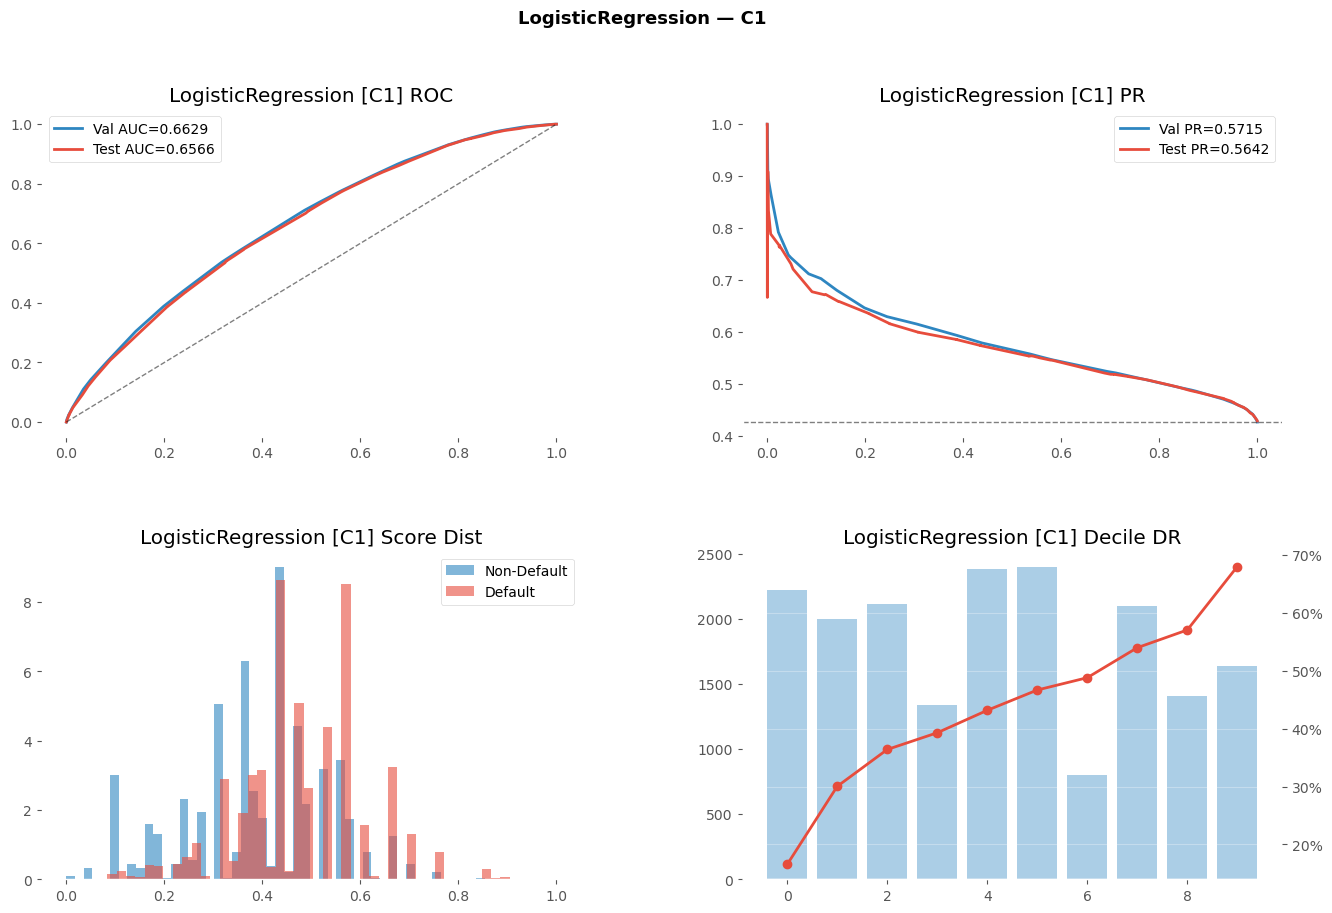

2026/07/06 19:06:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/06 19:06:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Tuning LR [C2plus] — 20 trials...


  0%|          | 0/20 [00:00<?, ?it/s]

  Best LR CV AUC: 0.7457 | C=0.08432
  CV AUC C2plus: 0.7457 ± 0.0017
  [C2plus|val] AUC=0.7481 Gini=0.4962 KS=0.3662 PR-AUC=0.3268 Brier=0.1166
  [C2plus|test] AUC=0.7433 Gini=0.4866 KS=0.3628 PR-AUC=0.3191 Brier=0.1184


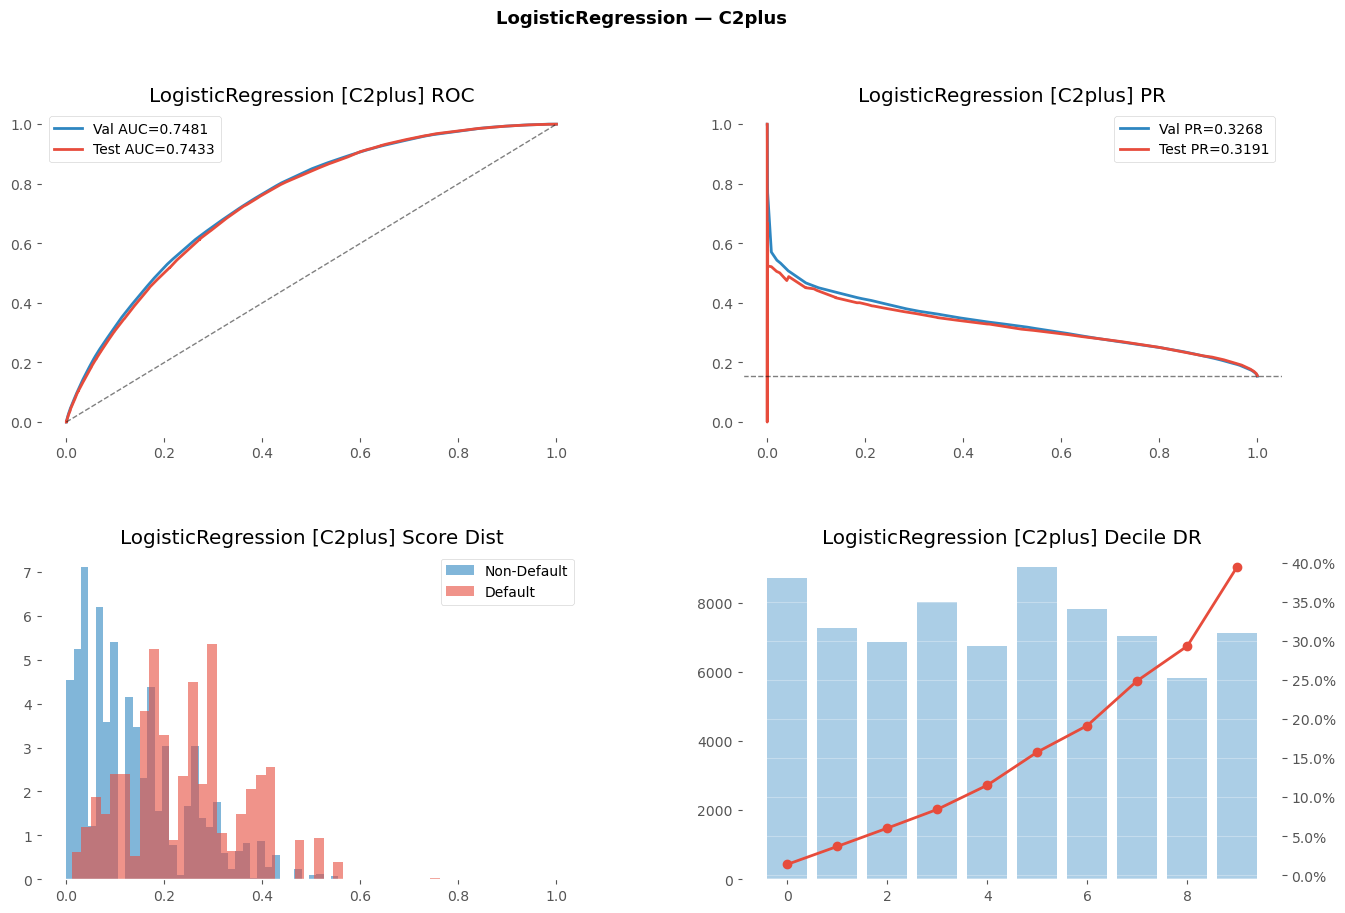

2026/07/06 22:56:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/06 22:56:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [48]:
# LOGISTIC REGRESSION BASELINE
print("LOGISTIC REGRESSION")

def tune_lr(X_train, y_train, groups, segment, n_trials=30):
    def objective(trial):
        C = trial.suggest_float('C', 1e-3, 10.0, log=True)
        sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True,
                                     random_state=SEED)
        aucs = []
        for tr, vl in sgkf.split(X_train, y_train, groups=groups):
            pre, _, _ = build_lr_rf_preprocessor(X_train)
            pipe = Pipeline([
                ('pre', pre),
                ('clf', LogisticRegression(
                    C=C, class_weight='balanced',
                    solver='saga', max_iter=1000,
                    random_state=SEED, n_jobs=-1))
            ])
            pipe.fit(X_train.iloc[tr], y_train.iloc[tr])
            p = pipe.predict_proba(X_train.iloc[vl])[:, 1]
            aucs.append(roc_auc_score(y_train.iloc[vl], p))
        return np.mean(aucs)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED))
    print(f'  Tuning LR [{segment}] — {n_trials} trials...')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f'  Best LR CV AUC: {study.best_value:.4f} | '
          f'C={study.best_params["C"]:.5f}')
    return study.best_params, study.best_value


def train_logistic_regression(X_train, y_train, X_val, y_val, X_test, y_test, groups, segment='C1'):
    best_params, best_cv = tune_lr(X_train, y_train, groups, segment, n_trials=20)
    best_C = best_params['C']

    with mlflow.start_run(run_name=f'LR_{segment}'):
        mlflow.log_params({
            'model': 'LogisticRegression', 'segment': segment,
            'C': best_C, 'class_weight': 'balanced',
            'split_strategy': 'random_user_70_15_15',
        })
        mlflow.log_metric('optuna_cv_auc', round(best_cv, 4))

        sgkf = StratifiedGroupKFold(n_splits=min(3, len(np.unique(groups))), shuffle=True, random_state=SEED)
        cv_aucs = []
        for tr, vl in sgkf.split(X_train, y_train, groups=groups):
            pre, _, _ = build_lr_rf_preprocessor(X_train)
            pipe = Pipeline([
                ('pre', pre),
                ('clf', LogisticRegression(
                    C=best_C, class_weight='balanced',
                    solver='saga', max_iter=1000,
                    random_state=SEED, n_jobs=-1))
            ])
            pipe.fit(X_train.iloc[tr], y_train.iloc[tr])
            p = pipe.predict_proba(X_train.iloc[vl])[:, 1]
            cv_aucs.append(roc_auc_score(y_train.iloc[vl], p))

        cv_mean, cv_std = np.mean(cv_aucs), np.std(cv_aucs)
        print(f'  CV AUC {segment}: {cv_mean:.4f} ± {cv_std:.4f}')
        mlflow.log_metrics({'cv_auc_mean': round(cv_mean,4),
                            'cv_auc_std':  round(cv_std, 4)})

        pre, _, _ = build_lr_rf_preprocessor(X_train)
        lr_pipe = Pipeline([
            ('pre', pre),
            ('clf', LogisticRegression(
                C=best_C, class_weight='balanced',
                solver='saga', max_iter=1000,
                random_state=SEED, n_jobs=-1))
        ])
        lr_pipe.fit(X_train, y_train)

        cal = CalibratedClassifierCV(lr_pipe, method='isotonic', cv='prefit')
        cal.fit(X_val, y_val)

        vm, _ = evaluate(cal, X_val,  y_val,  'val',  segment)
        tm, _ = evaluate(cal, X_test, y_test, 'test', segment)
        mlflow.log_metrics({**vm, **tm})

        fn = plot_evaluation(cal, X_val, y_val, X_test, y_test, 'LogisticRegression', segment)
        mlflow.log_artifact(fn)

        path = f'{MODELS_DIR}/lr_{segment.lower()}.pkl'
        joblib.dump(cal, path)
        mlflow.sklearn.log_model(cal, f'lr_{segment.lower()}')

    return cal, vm, tm

lr_c1, lr_c1_val, lr_c1_test = train_logistic_regression(X_train_c1, y_train_c1, X_val_c1, y_val_c1, X_test_c1,  y_test_c1,  g_train_c1, 'C1')
lr_c2, lr_c2_val, lr_c2_test = train_logistic_regression(X_train_c2, y_train_c2, X_val_c2, y_val_c2, X_test_c2,  y_test_c2,  g_train_c2, 'C2plus')

Random Forest with Optuna Tuning
  Tuning RF [C1] — 20 trials...


  0%|          | 0/20 [00:00<?, ?it/s]

  Best RF CV AUC: 0.6802 | params: {'n_estimators': 795, 'max_depth': 14, 'min_samples_leaf': 34, 'max_features': 0.3183956865423046}
  OOB [C1]: 0.6236
  [C1|val] AUC=0.6848 Gini=0.3697 KS=0.2635 PR-AUC=0.5894 Brier=0.2186
  [C1|test] AUC=0.6792 Gini=0.3584 KS=0.2536 PR-AUC=0.5828 Brier=0.2205


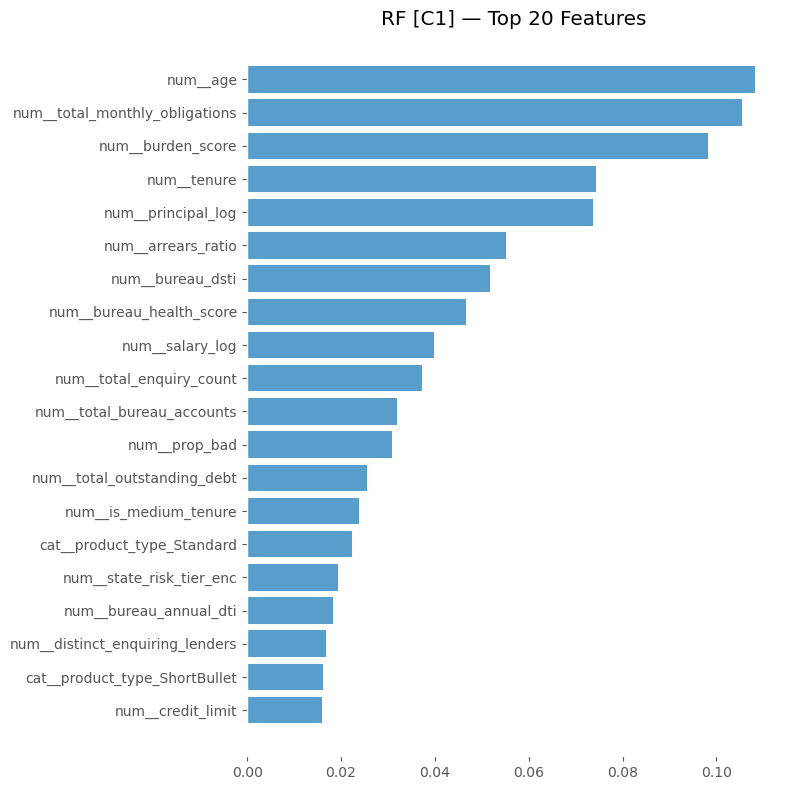

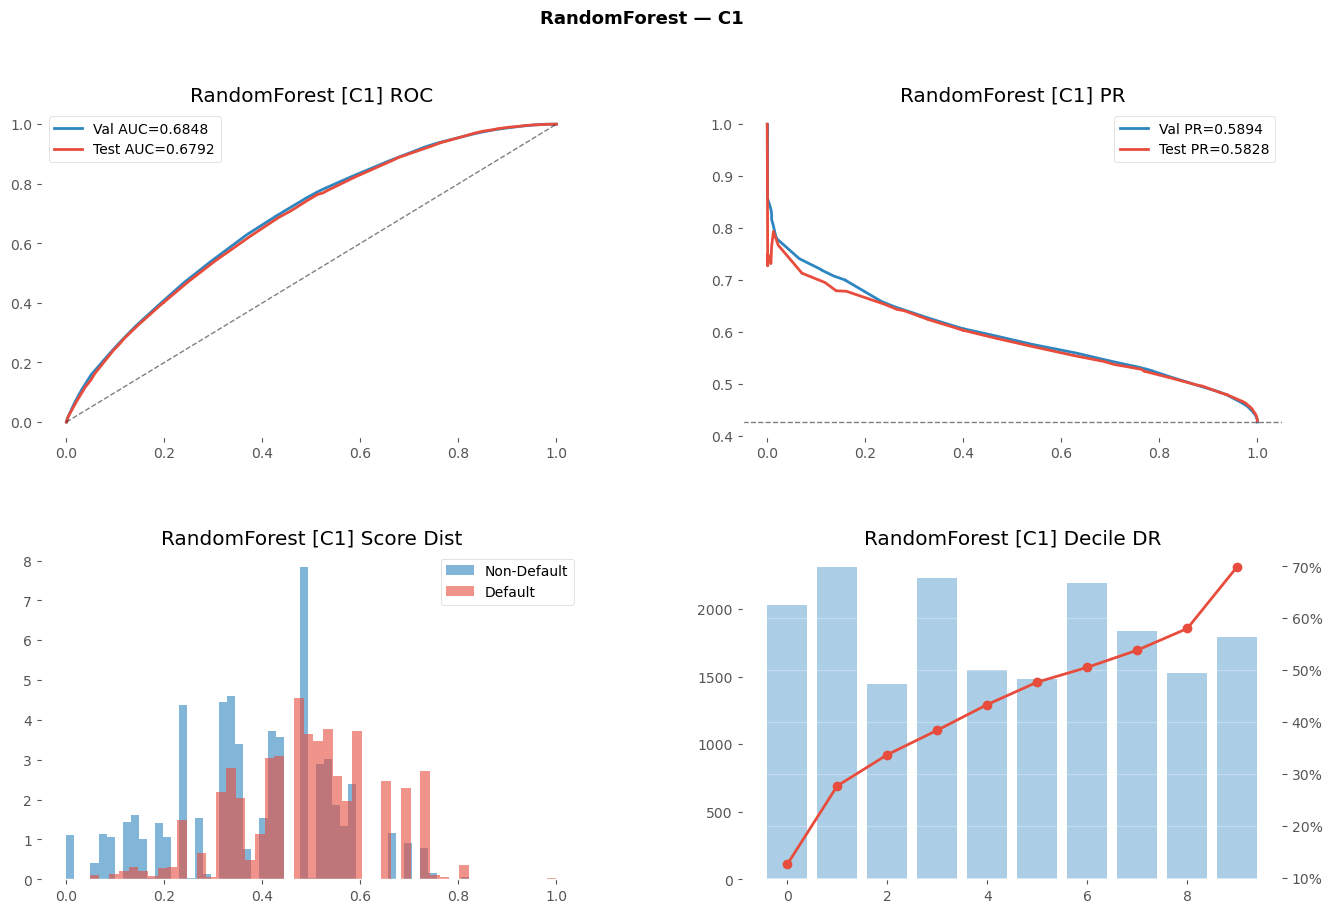

2026/07/07 00:30:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/07 00:30:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Tuning RF [C2plus] — 20 trials...


  0%|          | 0/20 [00:00<?, ?it/s]

  Best RF CV AUC: 0.7584 | params: {'n_estimators': 510, 'max_depth': 17, 'min_samples_leaf': 48, 'max_features': 0.6113875507308892}
  OOB [C2plus]: 0.6827
  [C2plus|val] AUC=0.7614 Gini=0.5228 KS=0.3874 PR-AUC=0.3447 Brier=0.1148
  [C2plus|test] AUC=0.7572 Gini=0.5144 KS=0.3789 PR-AUC=0.3380 Brier=0.1165


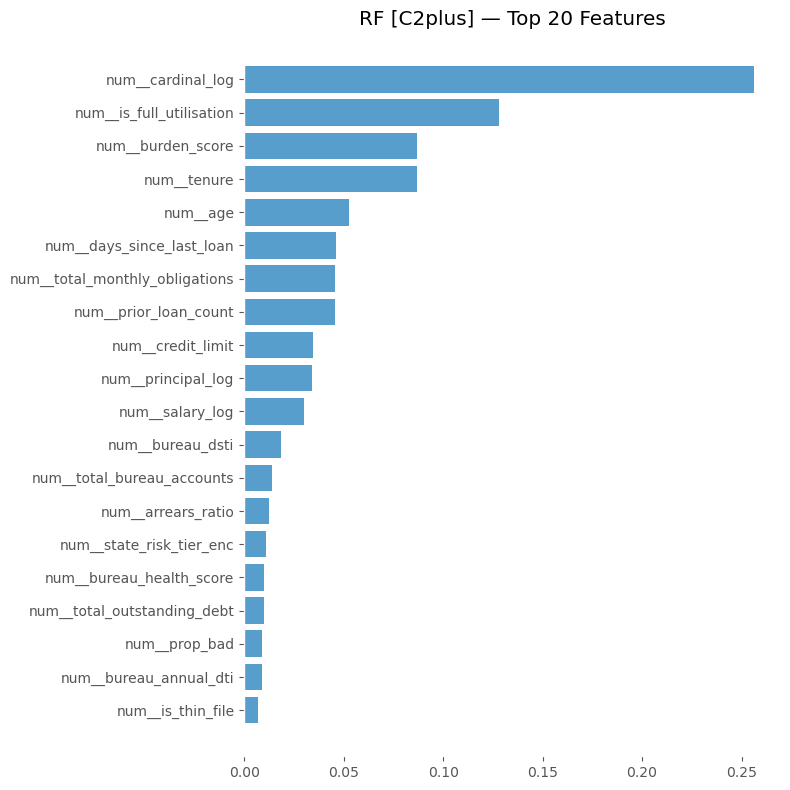

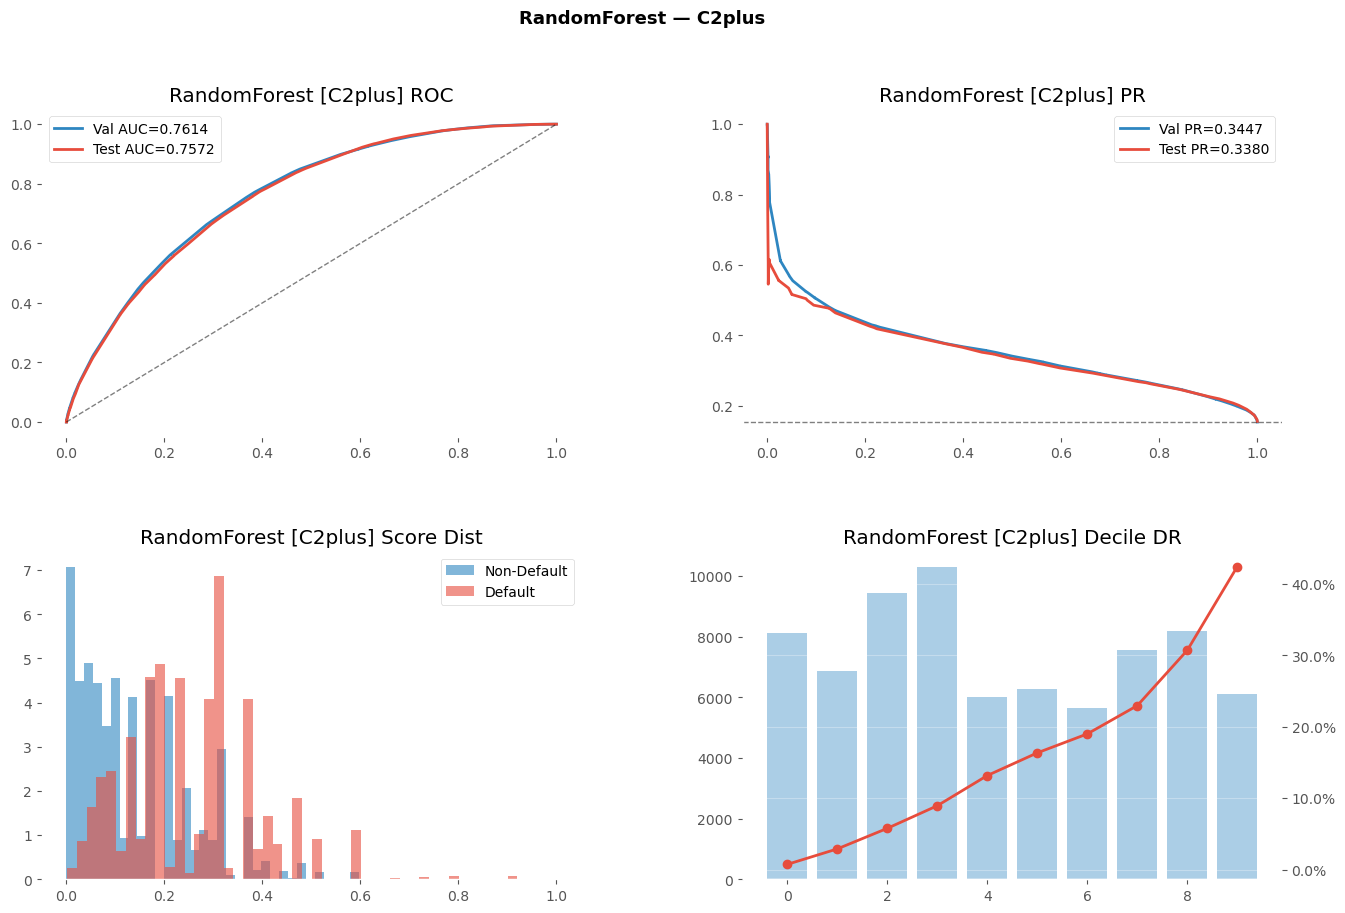

2026/07/07 06:29:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/07 06:29:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [49]:
# RANDOM FOREST WITH OPTUNA TUNING
print("Random Forest with Optuna Tuning")

def tune_rf(X_train, y_train, groups, segment, n_trials=30):
    """Find best RF hyperparameters using Optuna."""
    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
            'max_depth':        trial.suggest_int('max_depth', 5, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 200),
            'max_features':     trial.suggest_float('max_features', 0.2, 1.0),
            'class_weight':     'balanced_subsample',
            'random_state':     SEED,
            'n_jobs':          -1,
        }
        sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
        aucs = []
        for tr, vl in sgkf.split(X_train, y_train, groups=groups):
            pre, _, _ = build_lr_rf_preprocessor(X_train)
            pipe = Pipeline([
                ('pre', pre),
                ('clf', RandomForestClassifier(**params))
            ])
            pipe.fit(X_train.iloc[tr], y_train.iloc[tr])
            p = pipe.predict_proba(X_train.iloc[vl])[:, 1]
            aucs.append(roc_auc_score(y_train.iloc[vl], p))
        return np.mean(aucs)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5))
    print(f'  Tuning RF [{segment}] — {n_trials} trials...')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f'  Best RF CV AUC: {study.best_value:.4f} | '
          f'params: {study.best_params}')
    return study.best_params, study.best_value


def train_random_forest(X_train, y_train, X_val, y_val, X_test, y_test, groups, segment='C1'):
    best_params, best_cv = tune_rf(X_train, y_train, groups, segment, n_trials=20)

    with mlflow.start_run(run_name=f'RF_{segment}'):
        mlflow.log_params({
            'model': 'RandomForest', 'segment': segment,
            'split_strategy': 'random_user_70_15_15',
            **best_params,
        })
        mlflow.log_metric('optuna_cv_auc', round(best_cv, 4))

        pre, _, _ = build_lr_rf_preprocessor(X_train)
        rf_pipe = Pipeline([
            ('pre', pre),
            ('clf', RandomForestClassifier(
                **best_params,
                class_weight='balanced_subsample',
                oob_score=True,
                random_state=SEED,
                n_jobs=-1))
        ])
        rf_pipe.fit(X_train, y_train)

        oob = rf_pipe.named_steps['clf'].oob_score_
        print(f'  OOB [{segment}]: {oob:.4f}')
        mlflow.log_metric('oob_accuracy', round(oob, 4))

        cal = CalibratedClassifierCV(rf_pipe, method='isotonic', cv='prefit')
        cal.fit(X_val, y_val)

        vm, _ = evaluate(cal, X_val,  y_val,  'val',  segment)
        tm, _ = evaluate(cal, X_test, y_test, 'test', segment)
        mlflow.log_metrics({**vm, **tm})

        feat_names  = rf_pipe.named_steps['pre'].get_feature_names_out()
        importances = rf_pipe.named_steps['clf'].feature_importances_
        imp_df = (pd.DataFrame({'feature': feat_names,
                                 'importance': importances})
                  .sort_values('importance', ascending=False).head(20))
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
                color=BLUE, alpha=0.8)
        ax.set_title(f'RF [{segment}] — Top 20 Features')
        plt.tight_layout()
        imp_fn = f'{REPORTS_DIR}/rf_{segment.lower()}_importance.png'
        plt.savefig(imp_fn, dpi=150, bbox_inches='tight'); plt.show()
        mlflow.log_artifact(imp_fn)

        fn = plot_evaluation(cal, X_val, y_val, X_test, y_test, 'RandomForest', segment)
        mlflow.log_artifact(fn)

        path = f'{MODELS_DIR}/rf_{segment.lower()}.pkl'
        joblib.dump(cal, path)
        mlflow.sklearn.log_model(cal, f'rf_{segment.lower()}')

    return cal, vm, tm


rf_c1, rf_c1_val, rf_c1_test = train_random_forest(X_train_c1, y_train_c1, X_val_c1, y_val_c1, X_test_c1,  y_test_c1,  g_train_c1, 'C1')
rf_c2, rf_c2_val, rf_c2_test = train_random_forest(X_train_c2, y_train_c2, X_val_c2, y_val_c2, X_test_c2,  y_test_c2,  g_train_c2, 'C2plus')

LightGBM with Optuna Tuning
  Running 150 Optuna trials [C1]...


  0%|          | 0/150 [00:00<?, ?it/s]

  Best CV AUC: 0.6779
  Best params: {'early_stopping_rounds': 51, 'n_estimators': 1110, 'learning_rate': 0.005076947495215709, 'num_leaves': 222, 'max_depth': 10, 'min_child_samples': 51, 'subsample': 0.5092163662739232, 'colsample_bytree': 0.5391771170489609, 'reg_alpha': 0.006854982455521369, 'reg_lambda': 0.00020739202104565373, 'min_split_gain': 0.11531920126655885}


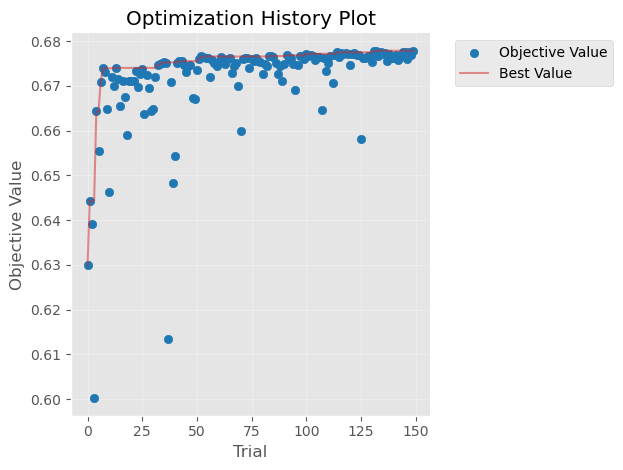

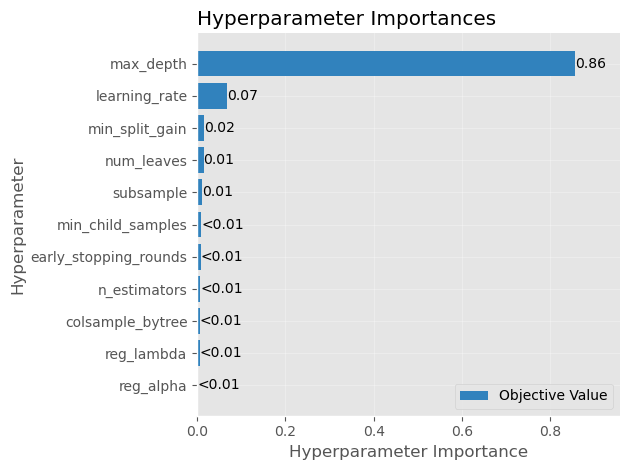

  [C1|val] AUC=0.6823 Gini=0.3646 KS=0.2590 PR-AUC=0.5867 Brier=0.2195
  [C1|test] AUC=0.6759 Gini=0.3517 KS=0.2513 PR-AUC=0.5803 Brier=0.2213
  Computing SHAP [C1]...


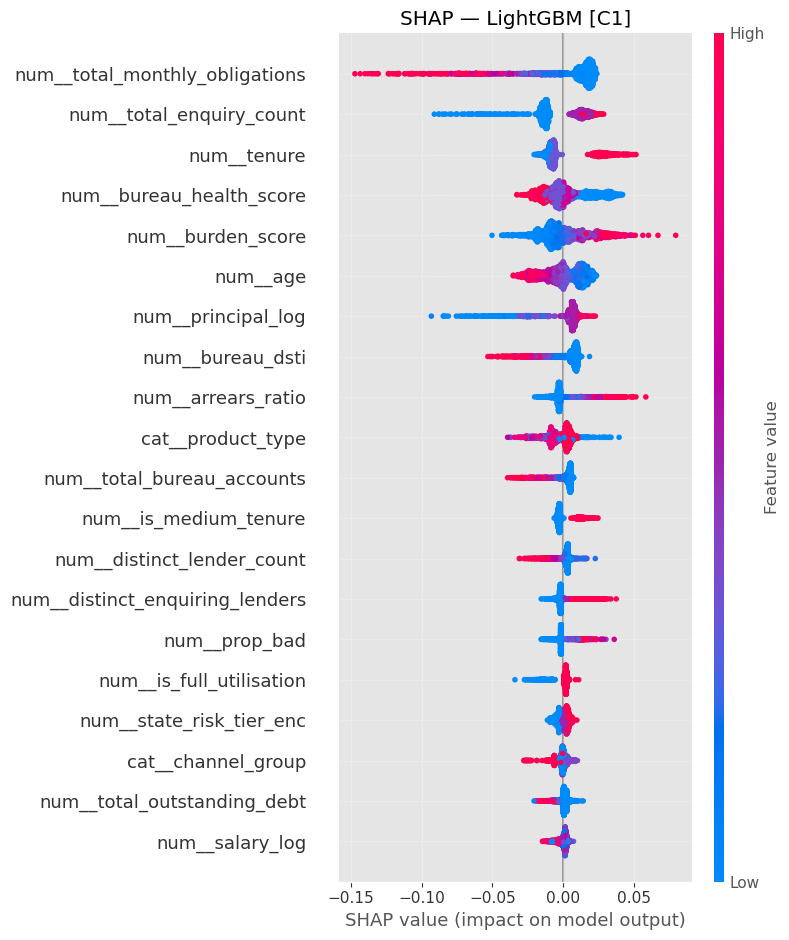

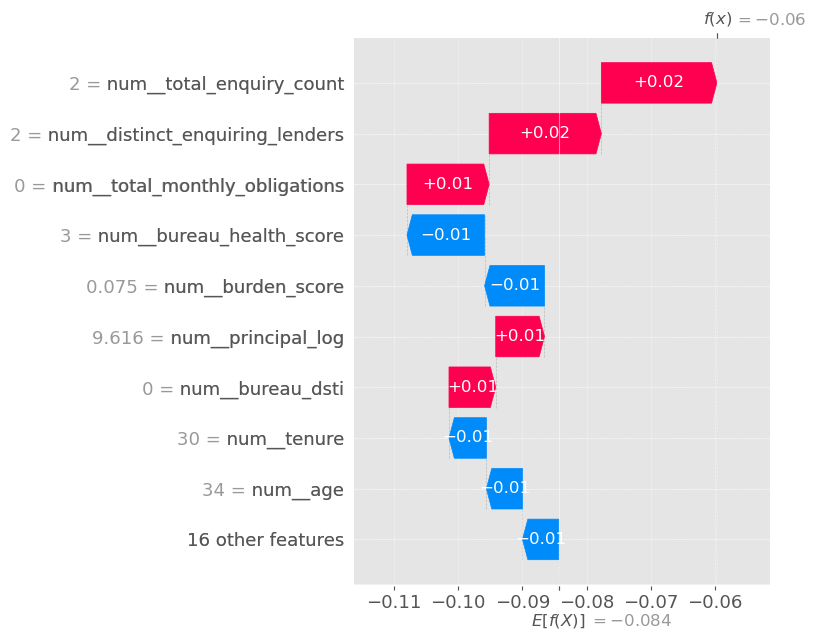

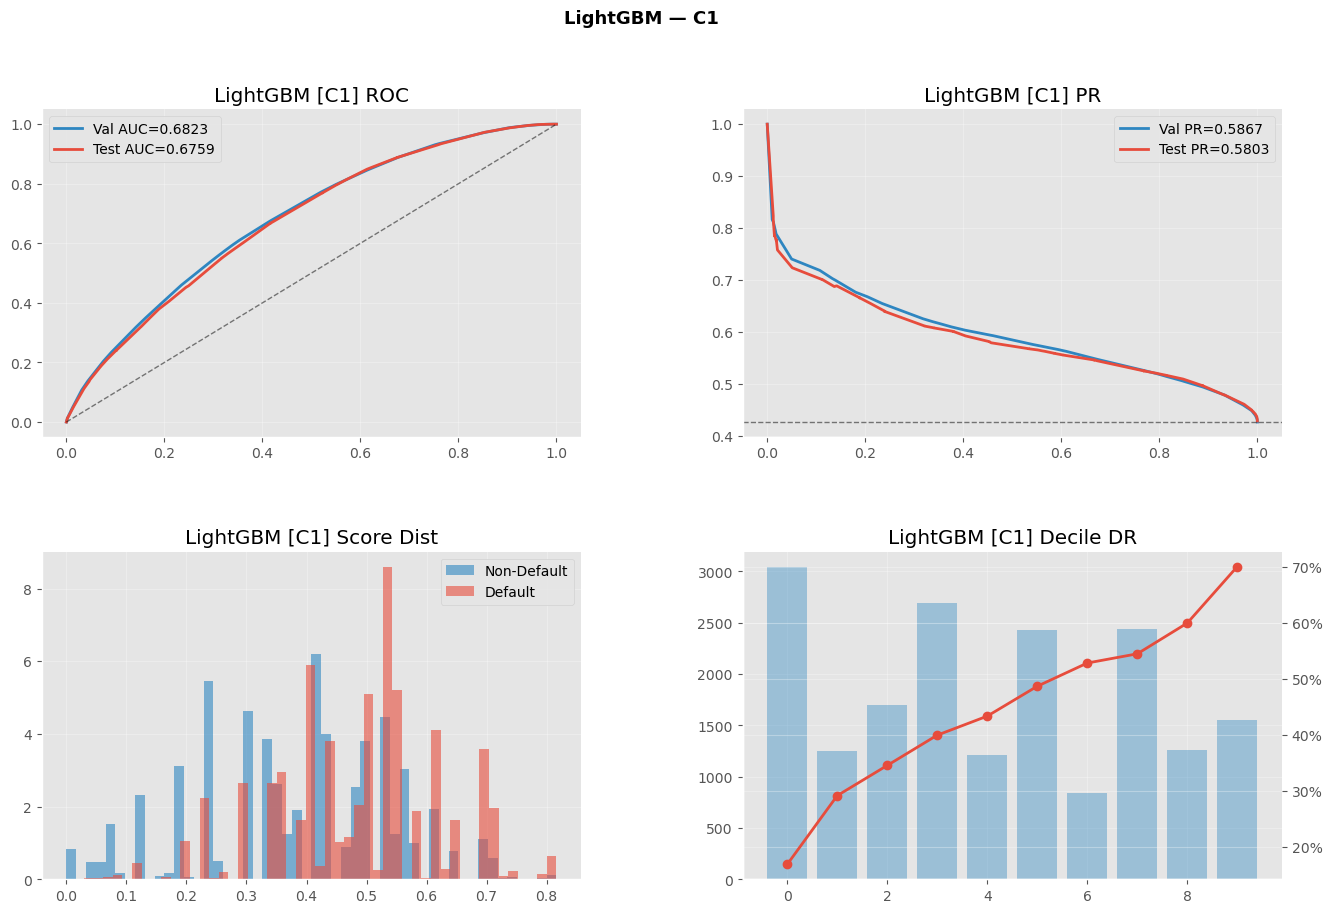

  Saved → ../models/lgbm_c1.pkl
  Running 150 Optuna trials [C2plus]...


  0%|          | 0/150 [00:00<?, ?it/s]

  Best CV AUC: 0.7566
  Best params: {'early_stopping_rounds': 84, 'n_estimators': 1648, 'learning_rate': 0.008798421688467499, 'num_leaves': 254, 'max_depth': 12, 'min_child_samples': 112, 'subsample': 0.9781751724038434, 'colsample_bytree': 0.6130475880782961, 'reg_alpha': 0.006335499373969238, 'reg_lambda': 0.0060857699454522, 'min_split_gain': 0.5248337489446179}


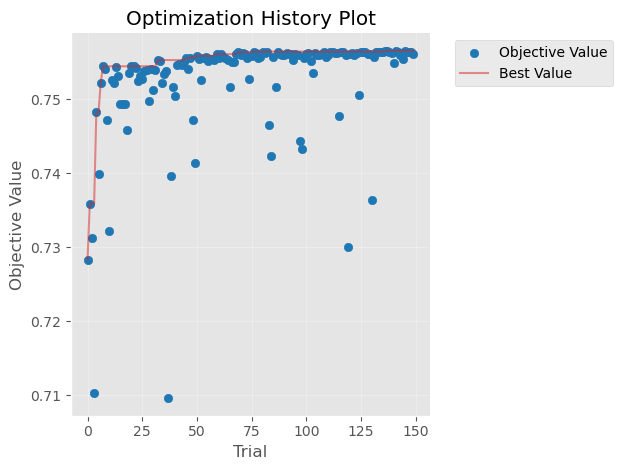

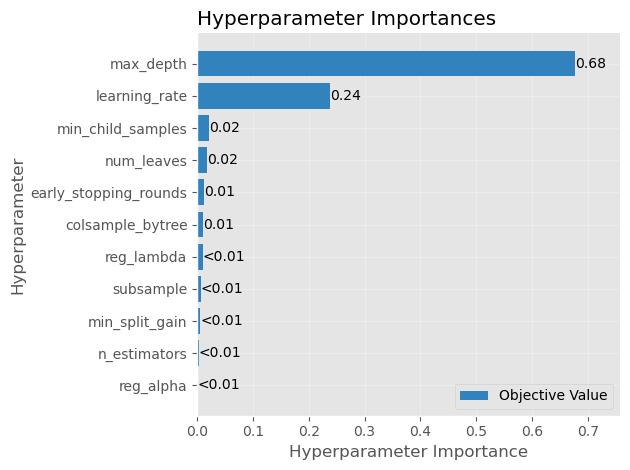

[100]	valid_0's binary_logloss: 0.423638
  [C2plus|val] AUC=0.7592 Gini=0.5185 KS=0.3817 PR-AUC=0.3423 Brier=0.1151
  [C2plus|test] AUC=0.7556 Gini=0.5112 KS=0.3770 PR-AUC=0.3364 Brier=0.1168
  Computing SHAP [C2plus]...


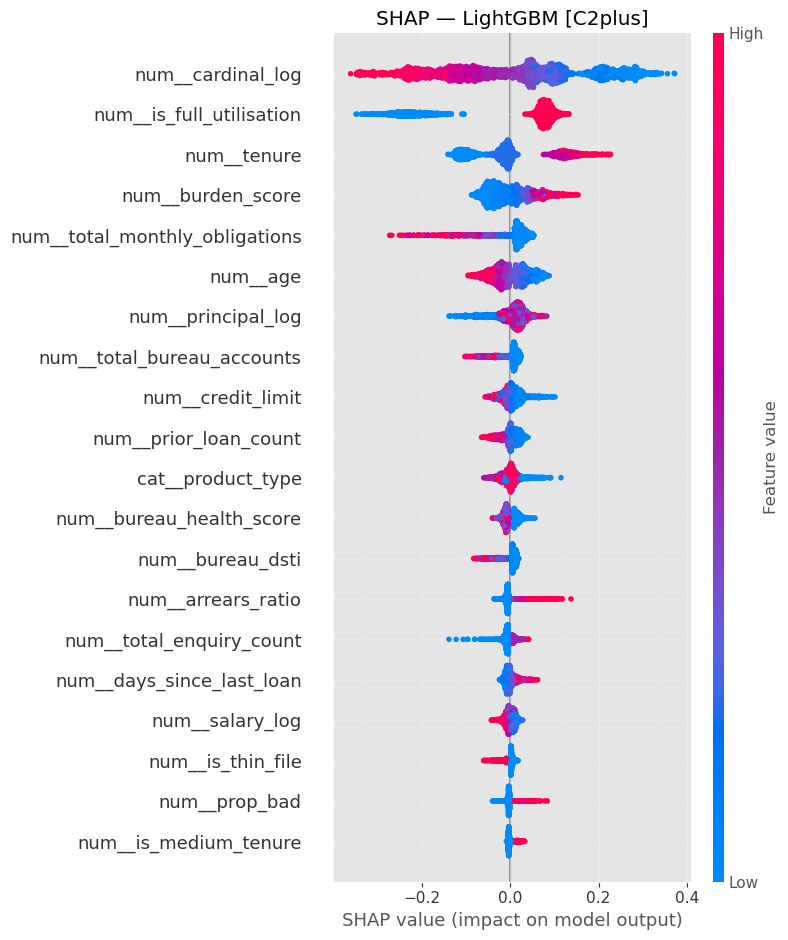

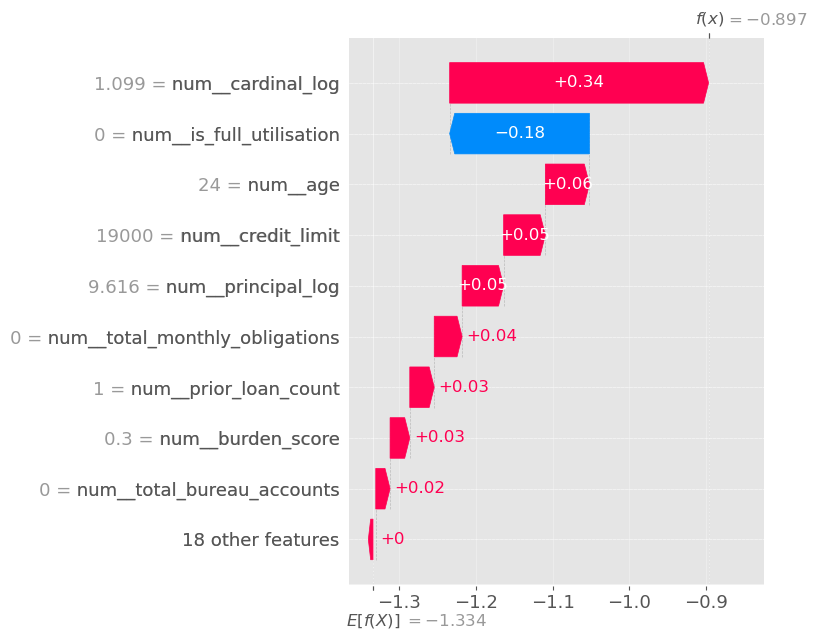

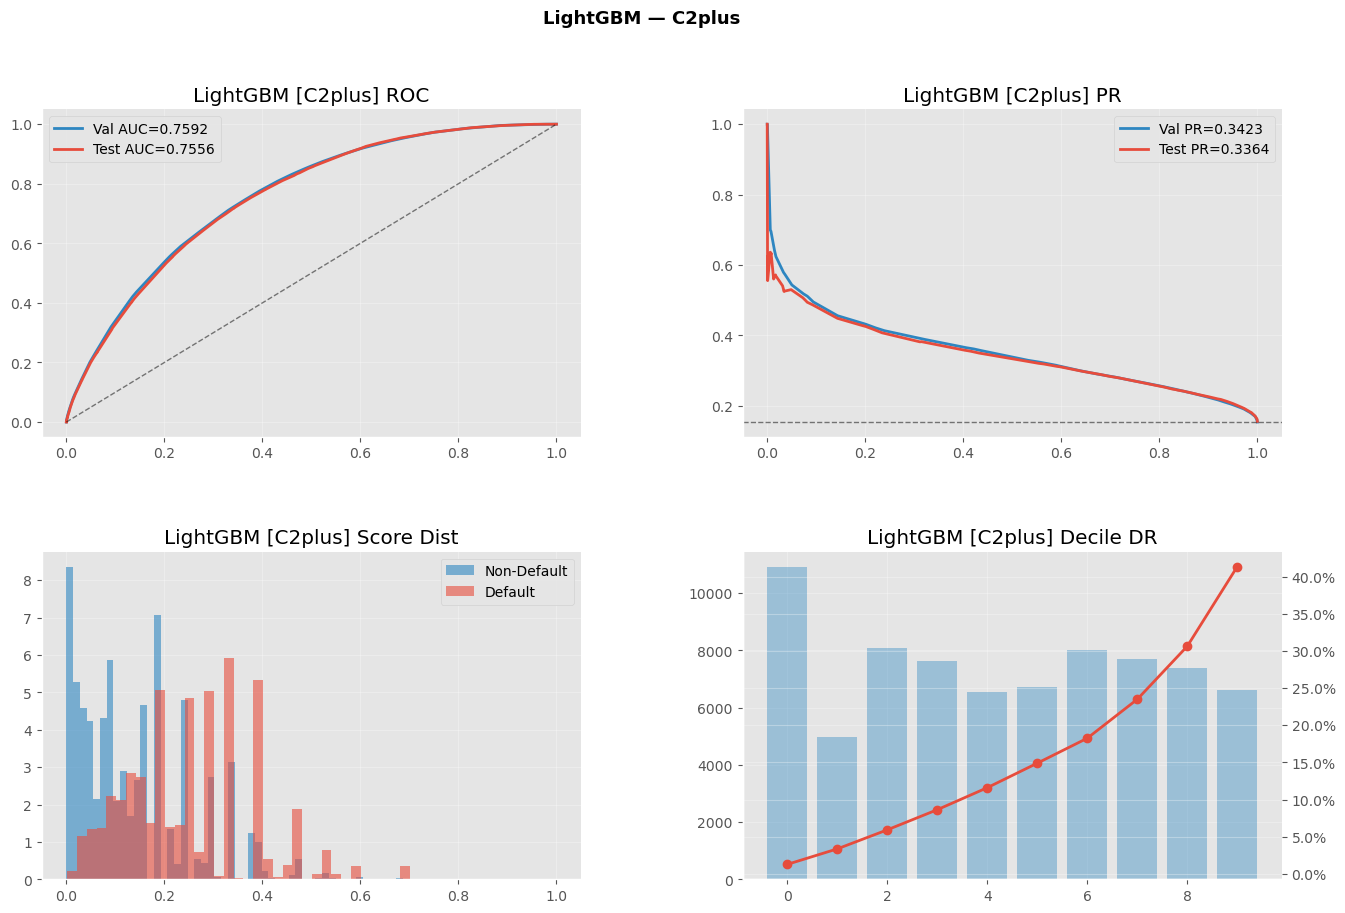

  Saved → ../models/lgbm_c2plus.pkl


In [50]:
# LIGHTGBM — OPTUNA TUNING + TRAINING
print("LightGBM with Optuna Tuning")

def tune_and_train_lightgbm(X_train, y_train, X_val, y_val, X_test, y_test, groups, segment='C1', n_trials=150):
    pre, num_cols, cat_cols = build_lgbm_preprocessor(X_train)

    def make_lgbm_pipeline(params):
        p = {k: v for k, v in params.items()
             if k != 'early_stopping_rounds'}
        p.update({'scale_pos_weight': SPW,
                  'random_state':     SEED,
                  'n_jobs':          -1,
                  'verbose':         -1})
        pre_fresh, _, _ = build_lgbm_preprocessor(X_train)
        return Pipeline([
            ('pre', pre_fresh),
            ('clf', lgb.LGBMClassifier(**p))
        ])

    # Optuna tuning 
    pre.fit(X_train)
    X_train_pp = pd.DataFrame(
        pre.transform(X_train),
        columns=pre.get_feature_names_out())
    X_val_pp = pd.DataFrame(
        pre.transform(X_val),
        columns=pre.get_feature_names_out())

    def objective(trial):
        early_stop = trial.suggest_int('early_stopping_rounds', 30, 150)
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 300, 2000),
            'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 20, 255),
            'max_depth':         trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 300),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
            'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 1.0),
            'scale_pos_weight':  SPW,
            'random_state':      SEED,
            'n_jobs':           -1,
            'verbose':          -1,
        }
        sgkf    = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
        cv_aucs = []
        for tr, vl in sgkf.split(X_train_pp, y_train, groups=groups):
            model = lgb.LGBMClassifier(**params)
            model.fit(
                X_train_pp.iloc[tr], y_train.iloc[tr],
                eval_set=[(X_train_pp.iloc[vl], y_train.iloc[vl])],
                callbacks=[lgb.early_stopping(early_stop, verbose=False),
                           lgb.log_evaluation(-1)],
            )
            p = model.predict_proba(X_train_pp.iloc[vl])[:, 1]
            cv_aucs.append(roc_auc_score(y_train.iloc[vl], p))
        return np.mean(cv_aucs)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=15, n_warmup_steps=5))
    print(f'  Running {n_trials} Optuna trials [{segment}]...')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f'  Best CV AUC: {study.best_value:.4f}')
    print(f'  Best params: {study.best_params}')

    best = study.best_params.copy()
    early_stop_best = best.pop('early_stopping_rounds', 50)

    # Optuna history plots
    for plot_fn, fname in [
        (optuna.visualization.matplotlib.plot_optimization_history,
         f'optuna_history_{segment.lower()}'),
        (optuna.visualization.matplotlib.plot_param_importances,
         f'optuna_importance_{segment.lower()}'),
    ]:
        try:
            plot_fn(study)
            plt.tight_layout()
            plt.savefig(f'{REPORTS_DIR}/{fname}.png',
                        dpi=150, bbox_inches='tight')
            plt.show()
        except Exception:
            pass

    final_params = {**best,
                    'scale_pos_weight': SPW,
                    'random_state': SEED,
                    'n_jobs': -1,
                    'verbose': -1}

    with mlflow.start_run(run_name=f'LGBM_{segment}'):
        mlflow.log_params({'model': 'LightGBM', 'segment': segment,
                           'n_trials': n_trials,
                           'cv_auc_optuna': round(study.best_value, 4),
                           'early_stopping_rounds': early_stop_best,
                           'split_strategy': 'random_user_70_15_15',
                           **final_params})

        pre_final, _, _ = build_lgbm_preprocessor(X_train)
        lgbm_pipe = Pipeline([
            ('pre', pre_final),
            ('clf', lgb.LGBMClassifier(**final_params))
        ])

        lgbm_pipe.named_steps['pre'].fit(X_train)
        X_train_arr = lgbm_pipe.named_steps['pre'].transform(X_train)
        X_val_arr   = lgbm_pipe.named_steps['pre'].transform(X_val)
        X_test_arr  = lgbm_pipe.named_steps['pre'].transform(X_test)

        feat_names  = lgbm_pipe.named_steps['pre'].get_feature_names_out()

        lgbm_pipe.named_steps['clf'].fit(
            X_train_arr, y_train,
            eval_set=[(X_val_arr, y_val)],
            callbacks=[lgb.early_stopping(early_stop_best, verbose=False),
                       lgb.log_evaluation(100)],
        )

        cal_lgbm = CalibratedClassifierCV(
            lgbm_pipe, method='isotonic', cv='prefit')
        cal_lgbm.fit(X_val, y_val)

        vm, _ = evaluate(cal_lgbm, X_val,  y_val,  'val',  segment)
        tm, _ = evaluate(cal_lgbm, X_test, y_test, 'test', segment)
        mlflow.log_metrics({**vm, **tm})

        # SHAP
        print(f'  Computing SHAP [{segment}]...')
        explainer   = shap.TreeExplainer(lgbm_pipe.named_steps['clf'])
        X_val_df    = pd.DataFrame(X_val_arr, columns=feat_names)
        shap_sample = X_val_df.sample(min(2000, len(X_val_df)), random_state=SEED)
        shap_vals   = explainer.shap_values(shap_sample)
        sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

        fig, _ = plt.subplots(figsize=(10, 8))
        shap.summary_plot(sv, shap_sample, show=False, max_display=20)
        plt.title(f'SHAP — LightGBM [{segment}]')
        plt.tight_layout()
        shap_fn = f'{REPORTS_DIR}/shap_{segment.lower()}.png'
        plt.savefig(shap_fn, dpi=150, bbox_inches='tight')
        plt.show()
        mlflow.log_artifact(shap_fn)

        try:
            ev = explainer.expected_value
            base = ev[1] if isinstance(ev, (list, np.ndarray)) else ev
            shap.waterfall_plot(
                shap.Explanation(
                    values=sv[0], base_values=base,
                    data=shap_sample.iloc[0],
                    feature_names=shap_sample.columns.tolist()),
                show=False)
            plt.tight_layout()
            wf_fn = f'{REPORTS_DIR}/shap_waterfall_{segment.lower()}.png'
            plt.savefig(wf_fn, dpi=150, bbox_inches='tight')
            plt.show()
            mlflow.log_artifact(wf_fn)
        except Exception as e:
            print(f'  Waterfall skipped: {e}')

        fn = plot_evaluation(cal_lgbm, X_val, y_val, X_test, y_test, 'LightGBM', segment)
        mlflow.log_artifact(fn)

        path = f'{MODELS_DIR}/lgbm_{segment.lower()}.pkl'
        joblib.dump(cal_lgbm, path)
        mlflow.log_artifact(path)
        print(f'  Saved → {path}')

    return cal_lgbm, vm, tm


lgbm_c1, lgbm_c1_val, lgbm_c1_test = tune_and_train_lightgbm(X_train_c1, y_train_c1, X_val_c1, y_val_c1, X_test_c1,  y_test_c1,  g_train_c1, 'C1', N_OPTUNA_TRIALS)
lgbm_c2, lgbm_c2_val, lgbm_c2_test = tune_and_train_lightgbm(X_train_c2, y_train_c2, X_val_c2, y_val_c2, X_test_c2,  y_test_c2,  g_train_c2, 'C2plus', N_OPTUNA_TRIALS)

SOFT VOTING ENSEMBLE
  [C1|val] AUC=0.6851 Gini=0.3702 KS=0.2656 PR-AUC=0.5990 Brier=0.2189
  [C1|test] AUC=0.6774 Gini=0.3548 KS=0.2561 PR-AUC=0.5897 Brier=0.2209


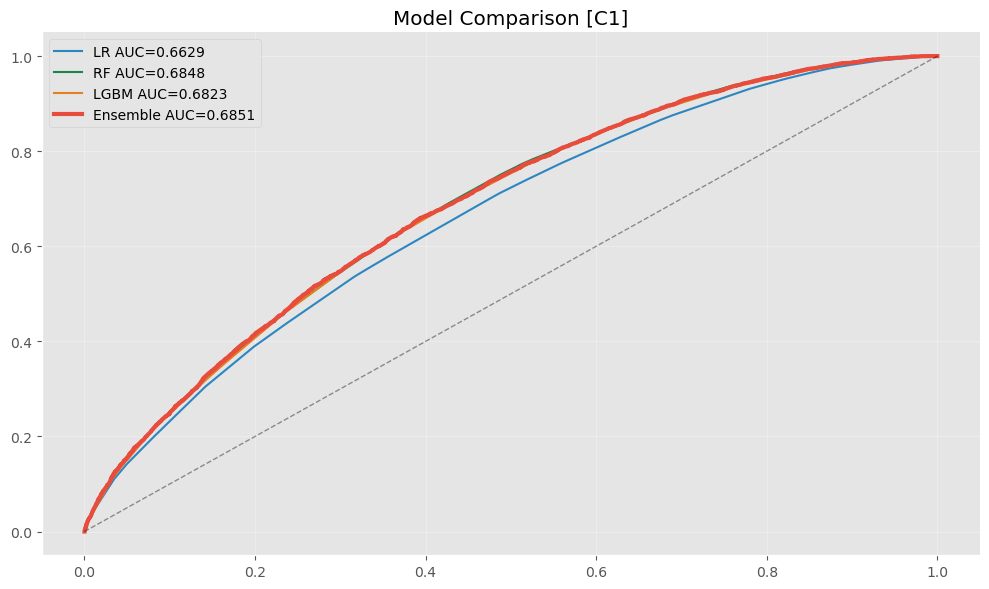

  [C2plus|val] AUC=0.7619 Gini=0.5237 KS=0.3870 PR-AUC=0.3571 Brier=0.1147
  [C2plus|test] AUC=0.7572 Gini=0.5144 KS=0.3816 PR-AUC=0.3474 Brier=0.1165


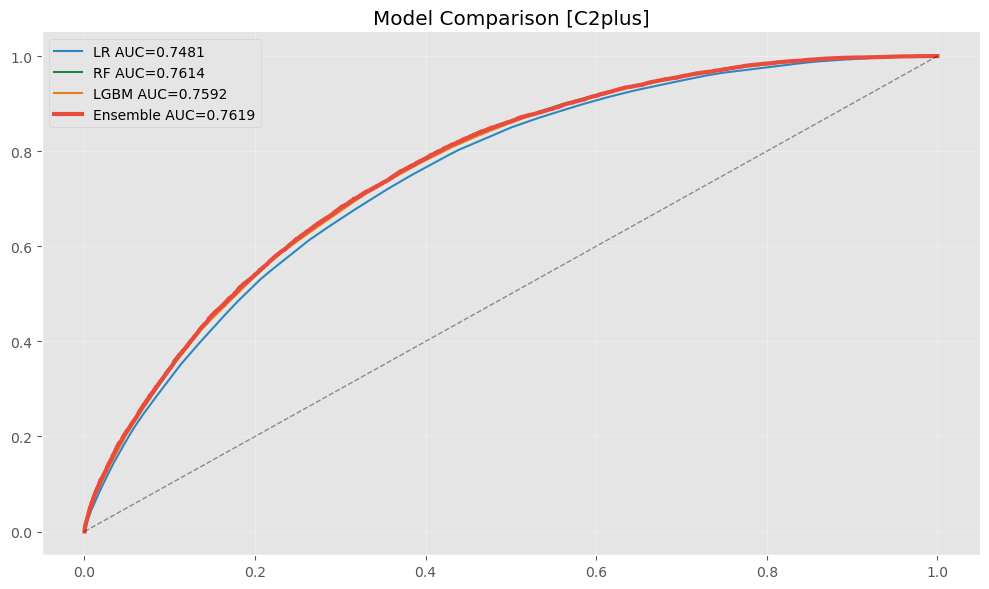

In [51]:
# SOFT VOTING ENSEMBLE
print("SOFT VOTING ENSEMBLE")

class EnsembleModel(BaseEstimator, ClassifierMixin):
    def __init__(self, lr, rf, lgbm):
        super().__init__()
        self.lr = lr
        self.rf = rf
        self.lgbm = lgbm
        self._estimator_type = 'classifier'
        self.classes_ = np.array([0, 1])

    def fit(self, X, y=None):
        return self

    def predict_proba(self, X):
        avg = ((self.lr.predict_proba(X)[:, 1]
              + self.rf.predict_proba(X)[:, 1]
              + self.lgbm.predict_proba(X)[:, 1]) / 3)
        return np.column_stack([1 - avg, avg])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    def get_params(self, deep=True):
        return {'lr': self.lr, 'rf': self.rf, 'lgbm': self.lgbm}

    def set_params(self, **p):
        for k, v in p.items(): setattr(self, k, v)
        return self


def train_voting_ensemble(lr, rf, lgbm, X_val, y_val, X_test, y_test, segment='C1'):
    ensemble = EnsembleModel(lr, rf, lgbm)

    with mlflow.start_run(run_name=f'Ensemble_{segment}'):
        mlflow.log_params({
            'model': 'SoftVotingEnsemble', 'segment': segment,
            'members': 'LR+RF+LGBM', 'weights': 'equal',
            'split_strategy': 'random_user_70_15_15',
        })
        vm, _ = evaluate(ensemble, X_val,  y_val,  'val',  segment)
        tm, _ = evaluate(ensemble, X_test, y_test, 'test', segment)
        mlflow.log_metrics({**vm, **tm})

        fig, ax = plt.subplots(figsize=(10, 6))
        for m, name, c, lw in [(lr,'LR',BLUE,1.5), (rf,'RF',GRN,1.5),
                                 (lgbm,'LGBM',ORG,1.5),
                                 (ensemble,'Ensemble',RED,3.0)]:
            p      = m.predict_proba(X_val)[:, 1]
            fpr, tpr, _ = roc_curve(y_val, p)
            ax.plot(fpr, tpr, color=c, lw=lw,
                    label=f'{name} AUC={roc_auc_score(y_val,p):.4f}')
        ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
        ax.set_title(f'Model Comparison [{segment}]')
        ax.legend(); plt.tight_layout()
        comp_fn = f'{REPORTS_DIR}/model_comparison_{segment.lower()}.png'
        plt.savefig(comp_fn, dpi=150, bbox_inches='tight'); plt.show()
        mlflow.log_artifact(comp_fn)

        path = f'{MODELS_DIR}/ensemble_{segment.lower()}.pkl'
        joblib.dump(ensemble, path)

    return ensemble, vm, tm


ens_c1, ens_c1_val, ens_c1_test = train_voting_ensemble(lr_c1, rf_c1, lgbm_c1, X_val_c1, y_val_c1, X_test_c1, y_test_c1, 'C1')
ens_c2, ens_c2_val, ens_c2_test = train_voting_ensemble(lr_c2, rf_c2, lgbm_c2, X_val_c2, y_val_c2, X_test_c2, y_test_c2, 'C2plus')

In [52]:
#  FINAL COMPARISON & MODEL SELECTION
print("\nFINAL COMPARISON & MODEL SELECTION")

def summarise(results, segment):
    rows = []
    for name, vm, tm in results:
        rows.append({'Model': name,
                     'Val AUC':  vm.get('val_auc'),
                     'Val Gini': vm.get('val_gini'),
                     'Val KS':   vm.get('val_ks'),
                     'Test AUC': tm.get('test_auc'),
                     'Test Gini':tm.get('test_gini'),
                     'Test KS':  tm.get('test_ks')})
    df_r = pd.DataFrame(rows).set_index('Model')
    print(f'\n── {segment} ──'); print(df_r.to_string())
    return df_r

res_c1 = [('LR',       lr_c1_val,   lr_c1_test),
           ('RF',       rf_c1_val,   rf_c1_test),
           ('LightGBM', lgbm_c1_val, lgbm_c1_test),
           ('Ensemble', ens_c1_val,  ens_c1_test)]
res_c2 = [('LR',       lr_c2_val,   lr_c2_test),
           ('RF',       rf_c2_val,   rf_c2_test),
           ('LightGBM', lgbm_c2_val, lgbm_c2_test),
           ('Ensemble', ens_c2_val,  ens_c2_test)]

df_c1 = summarise(res_c1, 'C1')
df_c2 = summarise(res_c2, 'C2+')

mm = {'LR': (lr_c1,lr_c2), 'RF': (rf_c1,rf_c2),
      'LightGBM': (lgbm_c1,lgbm_c2), 'Ensemble': (ens_c1,ens_c2)}
best_c1 = mm[df_c1['Val AUC'].idxmax()][0]
best_c2 = mm[df_c2['Val AUC'].idxmax()][1]
print(f'\nBest C1:  {df_c1["Val AUC"].idxmax()}')
print(f'Best C2+: {df_c2["Val AUC"].idxmax()}')

joblib.dump(best_c1, f'{MODELS_DIR}/best_model_c1.pkl')
joblib.dump(best_c2, f'{MODELS_DIR}/best_model_c2plus.pkl')


FINAL COMPARISON & MODEL SELECTION

── C1 ──
          Val AUC  Val Gini  Val KS  Test AUC  Test Gini  Test KS
Model                                                            
LR         0.6629    0.3258  0.2249    0.6566     0.3131   0.2182
RF         0.6848    0.3697  0.2635    0.6792     0.3584   0.2536
LightGBM   0.6823    0.3646  0.2590    0.6759     0.3517   0.2513
Ensemble   0.6851    0.3702  0.2656    0.6774     0.3548   0.2561

── C2+ ──
          Val AUC  Val Gini  Val KS  Test AUC  Test Gini  Test KS
Model                                                            
LR         0.7481    0.4962  0.3662    0.7433     0.4866   0.3628
RF         0.7614    0.5228  0.3874    0.7572     0.5144   0.3789
LightGBM   0.7592    0.5185  0.3817    0.7556     0.5112   0.3770
Ensemble   0.7619    0.5237  0.3870    0.7572     0.5144   0.3816

Best C1:  Ensemble
Best C2+: Ensemble


['../models/best_model_c2plus.pkl']

In [53]:
# RISK BAND THRESHOLDS
print('CALIBRATING RISK BAND THRESHOLDS')

def calibrate_thresholds(model, X_val, y_val, segment):
    p   = model.predict_proba(X_val)[:, 1]
    thr = {'very_low': float(np.percentile(p, 20)),
           'low':      float(np.percentile(p, 40)),
           'medium':   float(np.percentile(p, 65)),
           'high':     float(np.percentile(p, 85))}
    bands = pd.cut(p,
                   bins=[0,thr['very_low'],thr['low'],
                         thr['medium'],thr['high'],1.0],
                   labels=['Very Low','Low','Medium','High','Very High'],
                   include_lowest=True)
    summary = (pd.DataFrame({'band':bands,'target':y_val.values})
               .groupby('band')['target']
               .agg(['mean','count'])
               .rename(columns={'mean':'default_rate','count':'n'}))
    print(f'\n[{segment}] Risk Bands:'); print(summary.to_string())
    return thr

thr_c1 = calibrate_thresholds(best_c1, X_val_c1, y_val_c1, 'C1')
thr_c2 = calibrate_thresholds(best_c2, X_val_c2, y_val_c2, 'C2+')

artifacts_path = '../models/inference_artifacts.json'
with open(artifacts_path) as f:
    artifacts = json.load(f)
artifacts.update({
    'thresholds_c1':      thr_c1,
    'thresholds_c2plus':  thr_c2,
    'best_model_c1':      df_c1['Val AUC'].idxmax(),
    'best_model_c2plus':  df_c2['Val AUC'].idxmax(),
    'split_strategy':     'random_user_70_15_15',
    'features_c1':        FEATURES_C1,
    'features_c2plus':    FEATURES_C2PLUS,
})
with open(artifacts_path, 'w') as f:
    json.dump(artifacts, f, indent=2)

print('\nArtifacts updated.')
print('\nFinal test results:')
evaluate(best_c1, X_test_c1, y_test_c1, 'test', 'C1')
evaluate(best_c2, X_test_c2, y_test_c2, 'test', 'C2+')

CALIBRATING RISK BAND THRESHOLDS

[C1] Risk Bands:
           default_rate     n
band                         
Very Low       0.182781  3682
Low            0.355327  3698
Medium         0.447449  4586
High           0.542547  3690
Very High      0.660007  2753

[C2+] Risk Bands:
           default_rate      n
band                          
Very Low       0.017823  14981
Low            0.067978  14843
Medium         0.134973  18626
High           0.231322  14897
Very High      0.378567  11179

Artifacts updated.

Final test results:
  [C1|test] AUC=0.6774 Gini=0.3548 KS=0.2561 PR-AUC=0.5897 Brier=0.2209
  [C2+|test] AUC=0.7572 Gini=0.5144 KS=0.3816 PR-AUC=0.3474 Brier=0.1165


({'test_auc': 0.7572,
  'test_gini': 0.5144,
  'test_ks': np.float64(0.3816),
  'test_pr_auc': 0.3474,
  'test_brier': 0.1165},
 array([0.02398449, 0.16515224, 0.02398449, ..., 0.31868625, 0.44364914,
        0.24598417], shape=(73420,)))